In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.2-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.2-py3-none-any.whl (33 kB)
Note: you may need to restart the kernel to use updated packages.


/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(-1.9999886038228778+0j) (0.8102301677145771+0j) (0.9999999999535836-0j)
(-1.999647427780737+0j) (0.3423338793226822+0j) (0.9999999377572738-0j)
(-1.9997338059580876+0j) (-1.6558851497861777+0j) (0.9999998217113264-0j)


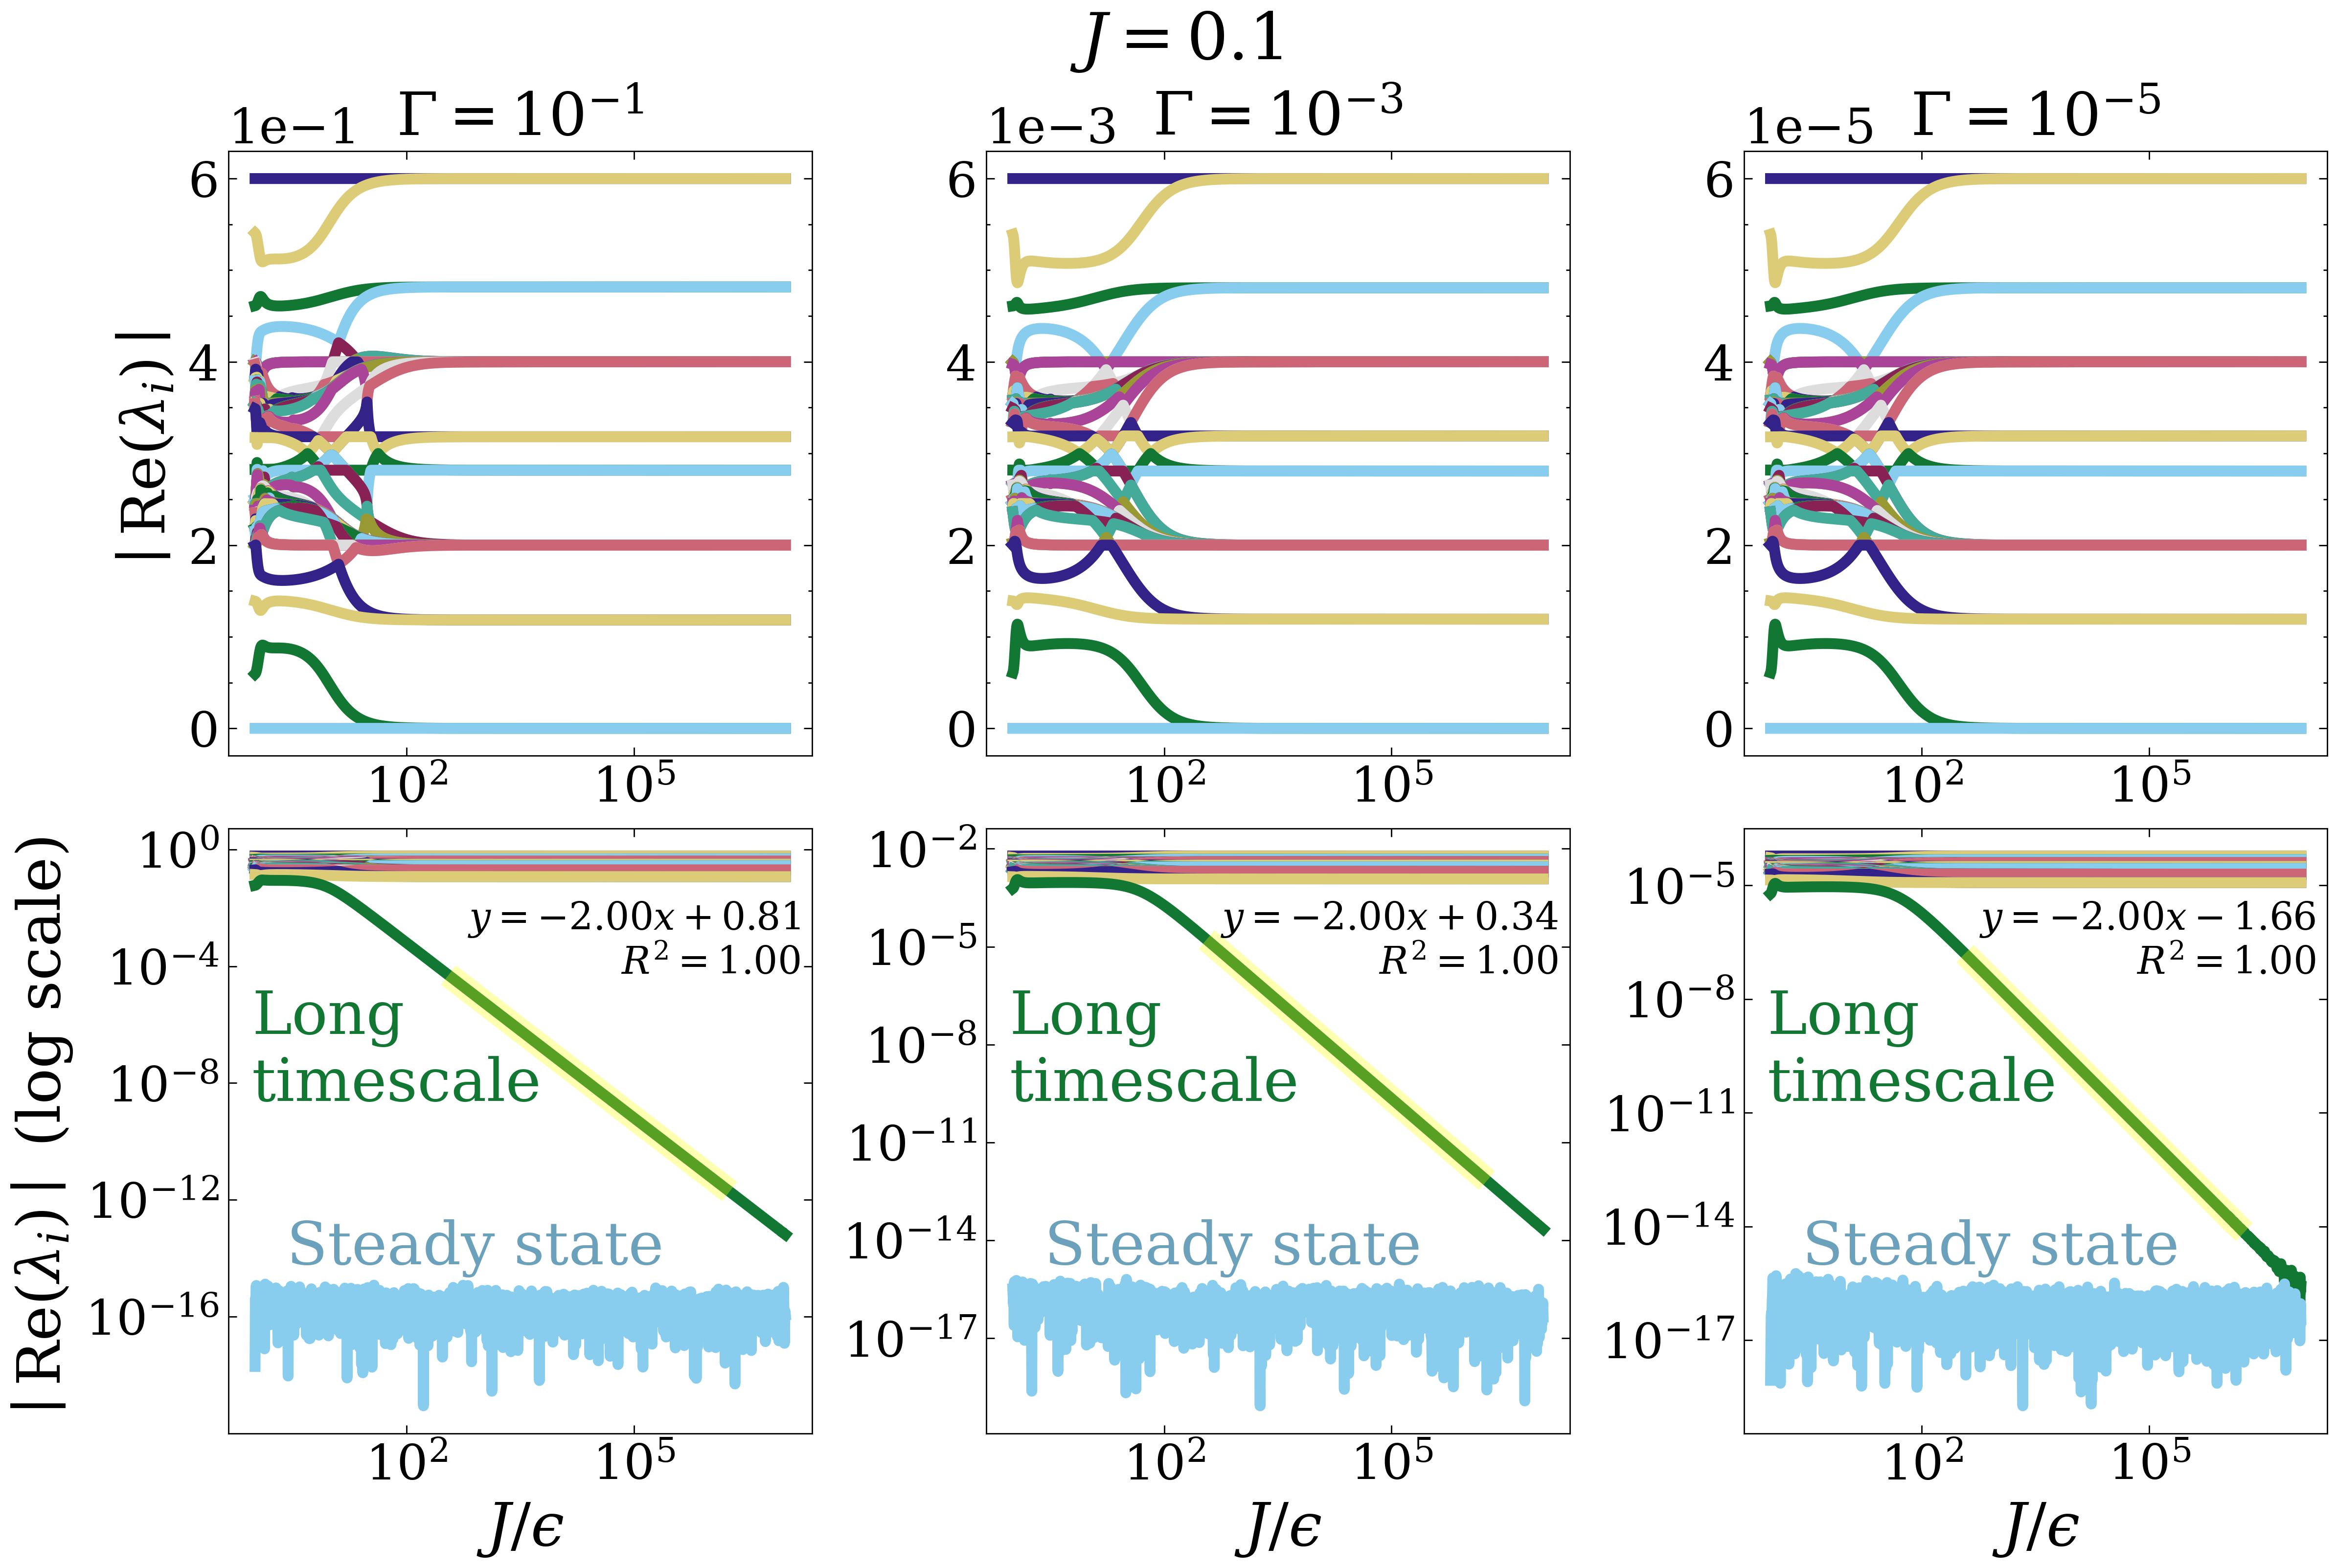

In [73]:
J_val = 0.1


datas = [
    np.loadtxt("gamma=1e-1; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5; J=0.1.dat", dtype=np.complex128),
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]

plt.style.use(['science', 'muted'])

plt.rcParams.update({
    "text.usetex": False,
    # General font
    "font.weight": "medium",
    "font.size": 22,
    # Axes
    "axes.labelsize": 22,
    "axes.labelweight": "medium",
    "axes.titlesize": 22,
    "axes.titleweight": "medium",
    # Ticks
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    # Legend
    "legend.fontsize": 22,
    "legend.title_fontsize": 22,
    # Figure
    "figure.titlesize": 24
})
fig, axs = plt.subplots(2,3, figsize=(12, 8), layout='constrained')






        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    axs[0][col].plot([],[])
    
    
    for i in range(evals.shape[1]//2): # skipping every other row, since we only want the real parts
        axs[0][col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        linewidth=4,
                        #alpha=1*0.9**i,
                        #linestyle="--"
                     )
    #axs[0][col].legend(title='Eigenvalue No.:', 
    #                #title_fontsize=12, 
    #                #fontsize=12, 
    #                ncol=3, 
    #                loc=(0.33, 0.06),
    #                columnspacing=0.5,
    #                handletextpad=0.3,
    #                handlelength=1.0,
    #                borderpad=0.4,
    #                labelspacing=0.3
    #               ) # plotting legend

    axs[0][col].set_xscale('log') # setting log scale for x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[0][col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[0][col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')

axs[0][0].set_ylabel(r'$\mid \mathrm{Re} (\lambda_i) \mid$')  # labelling y axis
   

     
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    axs[1][col].plot([],[])
    
    for i in range(evals.shape[1]//2): # skipping every other row, since we only want the real parts
        axs[1][col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        linewidth=4,
                        #alpha=1*0.9**i,
                        #linestyle="--"
                     )

    #axs[1][col].legend(title='Eigenvalue No.:', 
    #                #title_fontsize=12, 
    #                #fontsize=12, 
    #                ncol=3, 
    #                loc=(0.02, 0.3),
    #                columnspacing=0.5,
    #                handletextpad=0.3,
    #               handlelength=1.0,
    #                borderpad=0.4,
    #                labelspacing=0.3
    #               ) # plotting legend
    axs[1][col].set_xscale('log') # setting log scale for x axis
    axs[1][col].set_xlabel(r"$J / ϵ$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[1][col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    axs[1][col].set_yscale('log') # setting log scale for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[1][col].annotate("Steady state", xy=(0.1,0.28), xycoords="axes fraction", color="#6ca1bb", weight="medium")
    axs[1][col].annotate("Long\ntimescale", xy=(0.04,0.55), ha='left', xycoords="axes fraction", color="#117733", weight="medium")

axs[1][0].set_ylabel(r'$\mid \mathrm{Re} (\lambda_i) \mid$ (log scale)')  # labelling y axis
   

# linear regression of the form: y=mx+b
for col, data in enumerate(datas):
    eps = data[200:1000, 0] # specifically fitting to the linear portion of the long time-scale eval in the small epsilon limit
    evals = data[200:1000, 125] # specifically fitting to the linear portion of the long time-scale eval in the small epsilon limit
    m, b, r_value, p_value, std_err = scipy.stats.linregress(   np.log10(J_val/eps), np.log10(np.abs(evals))    )

    axs[1][col].plot(J_val/eps,np.abs(evals), linewidth=9, color="yellow", alpha=0.3)
    
    print(m, b, r_value**2)

    axs[1][col].annotate(fr"$y={np.real(m):.2f}x{"+" if np.real(b)>0 else "-"}{np.abs(b):.2f}$"+ "\n" + fr"$R^2 = {np.real(r_value)**2:.2f}$",
                         (0.98,0.76),
                         xycoords="axes fraction",
                         fontsize="14",
                         ha="right"
                    )




fig.suptitle(fr'$J={J_val}$')
'''
handles, labels = axs[0][0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Eigenvalue No.:',
    ncol=9,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.14),
    columnspacing=0.8,
    handletextpad=0.3,
    handlelength=1.6,
    borderpad=0.4,
)
'''

fig.savefig("manybody_splitting.pdf") 
fig.savefig("manybody_splitting.svg") 